<a href="https://colab.research.google.com/github/AISHWARYAARULSELVAN/IPCV/blob/main/EXP_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving CAM4.PNG to CAM4 (1).PNG
Saving CAM5.PNG to CAM5.PNG
Uploaded files: ['CAM4 (1).PNG', 'CAM5.PNG']

Image matrix:
 [[ 58  58  58 ... 123 123 123]
 [ 58  58  58 ... 123 123 123]
 [ 58  58  58 ... 123 123 123]
 ...
 [ 20  20  20 ... 117 117 117]
 [ 20  20  20 ... 117 117 117]
 [ 20  20  20 ... 117 117 117]]

Shape: (4000, 3000)
Data type: uint8
Size: 12000000


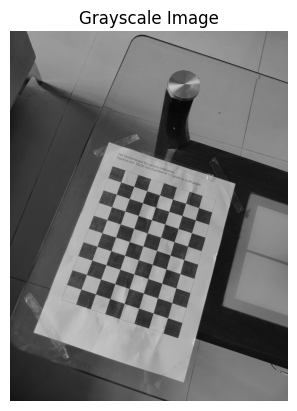


Color Image Shape: (3000, 4000, 3)
Size: 36000000
Data type: uint8


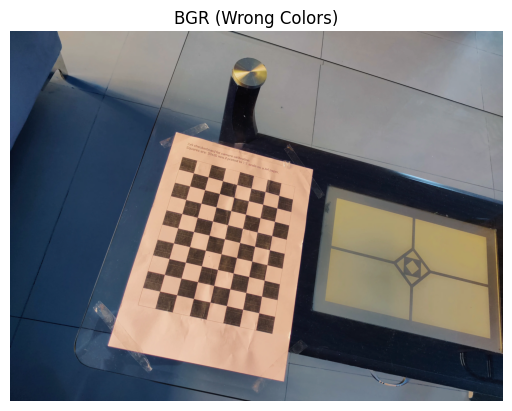

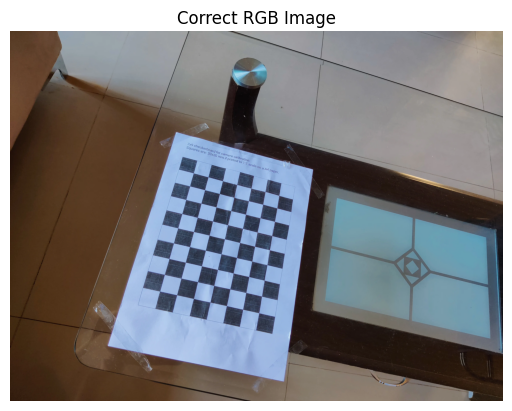

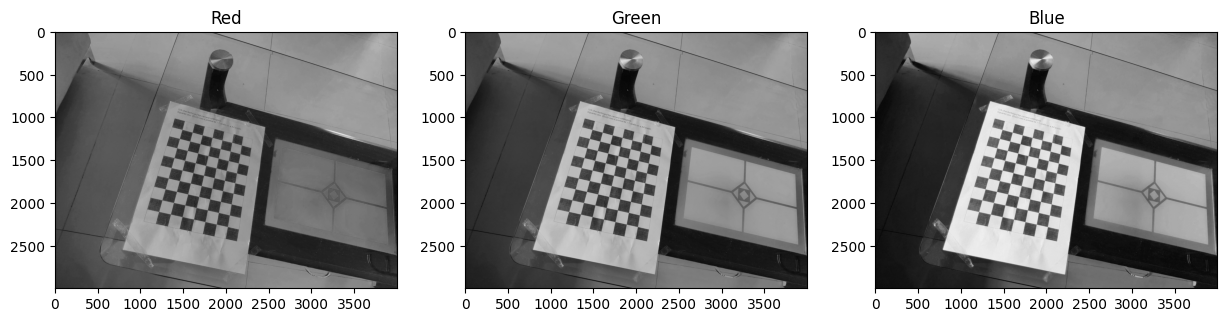

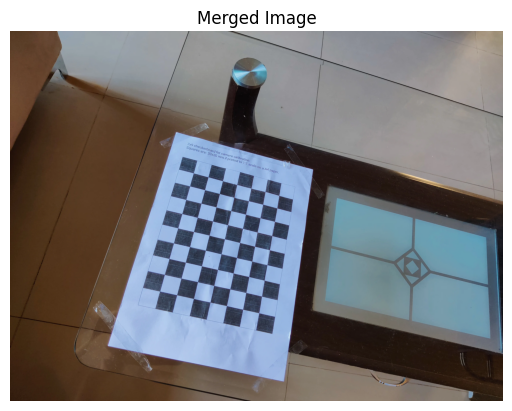

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# =========================
# 1. UPLOAD IMAGES
# =========================
uploaded = files.upload()

files_list = list(uploaded.keys())
print("Uploaded files:", files_list)

# Expecting 2 images:
# 0 -> checkerboard or left image
# 1 -> avocado or right image

img1_path = files_list[0]
img2_path = files_list[1]

# =========================
# 2. READ GRAYSCALE IMAGE
# =========================
cb_img = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)

print("\nImage matrix:\n", cb_img)

print("\nShape:", cb_img.shape)
print("Data type:", cb_img.dtype)
print("Size:", cb_img.size)

plt.imshow(cb_img, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

# =========================
# 3. READ COLOR IMAGE
# =========================
avacado_img = cv2.imread(img2_path, cv2.IMREAD_COLOR)

print("\nColor Image Shape:", avacado_img.shape)
print("Size:", avacado_img.size)
print("Data type:", avacado_img.dtype)

# =========================
# 4. WRONG DISPLAY (BGR)
# =========================
plt.imshow(avacado_img)
plt.title("BGR (Wrong Colors)")
plt.axis("off")
plt.show()

# =========================
# 5. FIX COLOR (BGR → RGB)
# =========================
avacado_rgb = cv2.cvtColor(avacado_img, cv2.COLOR_BGR2RGB)

plt.imshow(avacado_rgb)
plt.title("Correct RGB Image")
plt.axis("off")
plt.show()

# =========================
# 6. SPLIT CHANNELS
# =========================
b, g, r = cv2.split(avacado_img)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(r, cmap="gray")
plt.title("Red")

plt.subplot(1,3,2)
plt.imshow(g, cmap="gray")
plt.title("Green")

plt.subplot(1,3,3)
plt.imshow(b, cmap="gray")
plt.title("Blue")

plt.show()

# =========================
# 7. MERGE CHANNELS
# =========================
merged = cv2.merge((b, g, r))

plt.imshow(merged[:, :, ::-1])
plt.title("Merged Image")
plt.axis("off")
plt.show()

# =========================
# 8. HSV CONVERSION
# =========================
hsv = cv2.cvtColor(avacado_img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(h, cmap="gray")
plt.title("Hue")

plt.subplot(1,3,2)
plt.imshow(s, cmap="gray")
plt.title("Saturation")

plt.subplot(1,3,3)
plt.imshow(v, cmap="gray")
plt.title("Value")

plt.show()

# =========================
# 9. GRAYSCALE
# =========================
gray = cv2.cvtColor(avacado_img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()

# =========================
# 10. MODIFY HUE
# =========================
h_new = np.clip(h + 30, 0, 255).astype(np.uint8)

hsv_modified = cv2.merge((h_new, s, v))
rgb_modified = cv2.cvtColor(hsv_modified, cv2.COLOR_HSV2RGB)

plt.imshow(rgb_modified)
plt.title("Hue Modified Image")
plt.axis("off")
plt.show()

# =========================
# 11. SAVE IMAGE
# =========================
cv2.imwrite("output.jpg", avacado_rgb)
print("Saved as output.jpg")